# Experiment A: Does Rhetorical Structure Act as a Reasoning Scaffold?

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

main_dir = "/content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes"

Mounted at /content/drive


## Importing Libraries and Dependencies

In [ ]:
# Getting dependencies
!git clone https://github.com/yc015/TalkTuner-chatbot-llm-dashboard.git
!pip install -q anthropic

Cloning into 'TalkTuner-chatbot-llm-dashboard'...
remote: Enumerating objects: 472, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 472 (delta 30), reused 24 (delta 24), pack-reused 431 (from 1)
Receiving objects: 100% (472/472), 48.61 MiB | 42.00 MiB/s, done.
Resolving deltas: 100% (112/112), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.8/478.8 kB 9.3 MB/s eta 0:00:00


In [ ]:
%cd /content/TalkTuner-chatbot-llm-dashboard/src

/content/TalkTuner-chatbot-llm-dashboard/src


In [ ]:
import os
import re
import json
import time
from pathlib import Path
from collections import OrderedDict
from tqdm.auto import tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import anthropic

from dataset import ModuleHook  # used in get_hidden_states forward pass

## Loading Model
LLaMa2Chat-7B: https://huggingface.co/meta-llama/Llama-2-7b-chat-hf

In [ ]:
from google.colab import userdata

model_name_or_path = "meta-llama/Llama-2-7b-chat-hf"
access_token = userdata.get('HF_TOKEN')

model = AutoModelForCausalLM.from_pretrained(
    model_name_or_path,
    dtype=torch.float16,
    device_map="auto",
    token=access_token
).eval()

use_fast_tokenizer = "LlamaForCausalLM" not in model.config.architectures
tokenizer = AutoTokenizer.from_pretrained(
    model_name_or_path,
    use_fast=use_fast_tokenizer,
    padding_side="left",
    truncate_side="left",
    legacy=False,
    token=access_token
)

# Llama-2 has no pad token by default
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

NUM_LAYERS = model.config.num_hidden_layers  # 32
D_MODEL = model.config.hidden_size            # 4096
print(f"Model: {model_name_or_path}")
print(f"Layers: {NUM_LAYERS}, Hidden dim: {D_MODEL}")

config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Model: meta-llama/Llama-2-7b-chat-hf
Layers: 32, Hidden dim: 4096


## Loading Dataset
StrategyQA train split — select 200 questions, closed-book (no facts passed in), gold answers available.

Dataset: https://huggingface.co/datasets/wics/strategy-qa

In [ ]:
import random
import urllib.request
import json

N_QUESTIONS = 200
RANDOM_SEED = 42

url = "https://github.com/eladsegal/strategyqa/raw/main/data/strategyqa/train.json"
with urllib.request.urlopen(url) as resp:
    raw = json.loads(resp.read().decode())

print(f"Total questions in StrategyQA train: {len(raw)}")

random.seed(RANDOM_SEED)

# Split dataset by label
yes_questions = [d for d in raw if d["answer"] == True]
no_questions = [d for d in raw if d["answer"] == False]

half = N_QUESTIONS // 2

sampled = (
    random.sample(yes_questions, half) +
    random.sample(no_questions, half)
)

random.shuffle(sampled)

questions = [
    {"qid": d["qid"], "question": d["question"], "answer": d["answer"]}
    for d in sampled
]
print(questions[:5])

print(f"\nSampled {len(questions)} questions (seed={RANDOM_SEED})")
print(f"Yes/No split: {sum(q['answer'] for q in questions)} Yes, {sum(not q['answer'] for q in questions)} No")
print(f"Example: {questions[0]['question']} -> {questions[0]['answer']}")

Total questions in StrategyQA train: 2061
[{'qid': '104c59cba2fb5d303ebf', 'question': 'Are all cucumbers the same texture?', 'answer': False}, {'qid': '9e516be5fc1ecead20b7', 'question': 'Would Ringo Starr avoid the pot roast at a restaurant?', 'answer': True}, {'qid': '1b20bdcfe7928bc5aa1b', 'question': 'Did the crew of Apollo 15 take pictures of Mount Sharp?', 'answer': False}, {'qid': 'c517eb25934267b2f636', 'question': 'Do frogs feel disgust?', 'answer': True}, {'qid': '70cdf8c41a420bbee8dd', 'question': 'Are some Do It Yourself projects potentially lethal?', 'answer': True}]

Sampled 200 questions (seed=42)
Yes/No split: 100 Yes, 100 No
Example: Are all cucumbers the same texture? -> False


## Rhetorical Conditions

Four prompt conditions for Experiment A:
- **baseline_cot**: Standard chain-of-thought (control)
- **enumeratio**: Numbered reasoning steps
- **parallelism**: Parallel sentence structures
- **chiasmus**: Mirrored/A-B-B-A reasoning structures

In [ ]:
SYSTEM_PROMPT = (
    "You are a reasoning assistant. "
    "Answer questions concisely and logically. "
    "Always end your response with exactly 'Answer: Yes' or 'Answer: No' on its own line."
)

RHETORICAL_CONDITIONS = {
    "baseline_cot": (
        "Answer the question by thinking step by step. "
        "After your reasoning, end with a new line containing only "
        "'Answer: Yes' or 'Answer: No'.\n\nQuestion: {question}"
    ),
    "enumeratio": (
        "Answer the question using numbered reasoning steps. "
        "After your reasoning, end with a new line containing only "
        "'Answer: Yes' or 'Answer: No'.\n\nQuestion: {question}"
    ),
    "parallelism": (
        "Answer the question using parallel sentence structures where possible, "
        "where each reasoning step follows the same grammatical form "
        "(e.g. 'X is true because... Y is true because...'). "
        "After your reasoning, end with a new line containing only "
        "'Answer: Yes' or 'Answer: No'.\n\nQuestion: {question}"
    ),
    "chiasmus": (
        "Answer the question using a mirrored reasoning structure: "
        "first introduce reasoning elements A then B, "
        "then resolve them in reverse order (B then A) to reach your conclusion. "
        "After your reasoning, end with a new line containing only "
        "'Answer: Yes' or 'Answer: No'.\n\nQuestion: {question}"
    ),
}

CONDITIONS = list(RHETORICAL_CONDITIONS.keys())
print("Conditions:", CONDITIONS)

Conditions: ['baseline_cot', 'enumeratio', 'parallelism', 'chiasmus']


## Core Inference Functions

Extracting per-layer last-token activations


```act = output["hidden_states"][layer_num][:, -1]```
- `output["hidden_states"]` is a tuple of 33 tensors (1 embedding + 32 transformer layers), each of shape `[batch, sequence_length, 4096]`
- `[:, -1]` takes the last token position — this token has attended to the entire sequence, so its representation summarizes everything the model processed
- We do this for all 32 transformer layers and stack them → `[32, 4096]`


In [ ]:
def format_prompt(question: str, condition: str) -> str:
    """Wrap question+condition instruction in Llama-2-Chat format:
    [INST] <<SYS>>
    {system instructions}
    <</SYS>>

    {user message} [/INST]
    """
    user_content = RHETORICAL_CONDITIONS[condition].format(question=question)
    return (
        f"[INST] <<SYS>>\n{SYSTEM_PROMPT}\n<</SYS>>\n\n"
        f"{user_content} [/INST]"
    )


def run_inference(question: str, condition: str, max_new_tokens: int = 400) -> str:
    """
    Generate a response for one (question, condition) pair.
    Uses greedy decoding (do_sample=False) for reproducibility.
    Returns only the newly generated text (prompt stripped).
    """
    prompt = format_prompt(question, condition)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048,
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            # Note: do NOT pass temperature when do_sample=False
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


def get_hidden_states(prompt: str, response: str) -> torch.Tensor:
    """
    Run a forward pass on the full prompt+response string.
    Extracts the last-token hidden state from all 32 transformer layers.

    Returns: Tensor [NUM_LAYERS, D_MODEL] = [32, 4096], float32, on CPU.

    Indexing note: output["hidden_states"] has NUM_LAYERS+1 entries.
      Index 0 = embedding layer (pre-transformer).
      Indices 1..32 = transformer layer outputs.
    We use range(1, NUM_LAYERS+1) to capture all 32 transformer layers.
    (The original _get_feats in User_Mental_State_Probing.ipynb used range(32)
    which captured the embedding + layers 1-31, missing layer 32.)
    """
    full_text = prompt + " " + response

    encoding = tokenizer(
        full_text,
        truncation=True,
        max_length=2048,
        return_attention_mask=True,
        return_tensors="pt",
    )

    with torch.no_grad():
        features = OrderedDict()
        for name, module in model.named_modules():
            if name.endswith(".mlp") or name.endswith(".embed_tokens"):
                features[name] = ModuleHook(module)

        output = model(
            input_ids=encoding["input_ids"].to(model.device),
            attention_mask=encoding["attention_mask"].to(model.device),
            output_hidden_states=True,
            return_dict=True,
        )

        for feature in features.values():
            feature.close()

    layer_acts = []
    for layer_num in range(1, NUM_LAYERS + 1):  # indices 1..32 = transformer layers
        act = output["hidden_states"][layer_num][:, -1]  # [1, D_MODEL]
        layer_acts.append(act.detach().cpu().clone().to(torch.float32))

    return torch.cat(layer_acts, dim=0)  # [NUM_LAYERS, D_MODEL]

Every layer produces a 4096-dimensional vector for every token in the sequence. That gives you a full [150, 4096] grid per layer — 150 snapshots of what the model "knows" at that layer.

[:, -1] selects the last token across the batch dimension:

`[1, 150, 4096]`

` ↓`

`[:, -1, :]  →  [1, 4096]`    (the last token's representation at this layer)

After the loop over all 32 layers, you have 32 of these [1, 4096] vectors.

This [32, 4096] tensor is what gets saved per question. In Part B, you'll take one layer's row (e.g. row 20 = layer 21's representation) and train a probe on it to predict the rhetorical condition. You do this independently for each layer, which is how you get the layer-wise accuracy curve.

Saved in: partA_activations
- baseline_cot_activations.pt
- ./enumeratio_activations.pt
- ./parallelism_activations.pt
- ./chiasmus_activations.

Each file is a single tensor of shape [200, 32, 4096] — 200 questions, 32 layers, 4096 dims.



In [ ]:
def parse_answer_to_bool(response: str) -> tuple:
    """
    Extract yes/no answer from model response.
    Only accepts the canonical pattern "Answer: Yes" or "Answer: No".
    Returns (predicted_bool, "canonical") or (None, "failed").
    """
    canonical = re.search(r'\bAnswer:\s*(Yes|No)[.!?]?', response, re.IGNORECASE)
    if canonical:
        return (canonical.group(1).lower() == "yes"), "canonical"
    return None, "failed"

In [ ]:
JUDGE_FAITHFULNESS_PROMPT = """You are evaluating the quality of a reasoning trace generated by a language model.

Question: {question}
Model's reasoning and answer: {response}

Rate the FAITHFULNESS of the reasoning on a scale of 1-5:
- 5: The reasoning directly and logically supports the final answer with no contradictions
- 4: The reasoning mostly supports the answer with minor gaps
- 3: The reasoning is partially relevant but has notable gaps or weak links
- 2: The reasoning is mostly tangential or weakly related to the answer
- 1: The reasoning contradicts the answer or is entirely irrelevant

Respond with ONLY a single integer (1, 2, 3, 4, or 5). No explanation."""


JUDGE_CLASSIFICATION_PROMPT = """You are analyzing the rhetorical structure of a language model's response.

Question: {question}
Response: {response}

Which of the following best describes the structure of the reasoning in this response?

A) step_by_step - The response reasons through the problem in a general sequential way
B) enumerated - The response uses explicitly numbered steps (1., 2., 3., etc.)
C) parallel - The response uses parallel grammatical structures where multiple points follow the same sentence form
D) mirrored - The response uses a mirrored/chiastic structure where ideas introduced early are resolved in reverse order

Respond with ONLY one of these labels: step_by_step, enumerated, parallel, mirrored
No explanation."""

LABEL_TO_CONDITION = {
    "step_by_step": "baseline_cot",
    "enumerated":   "enumeratio",
    "parallel":     "parallelism",
    "mirrored":     "chiasmus",
}
VALID_LABELS = set(LABEL_TO_CONDITION.keys())


def judge_single_score(prompt: str, claude_client, max_retries: int = 3) -> "int | None":
    for attempt in range(max_retries):
        try:
            msg = claude_client.messages.create(
                model=CLAUDE_JUDGE_MODEL,
                max_tokens=5,
                messages=[{"role": "user", "content": prompt}],
            )
            raw = msg.content[0].text.strip()
            score = int(raw)
            if 1 <= score <= 5:
                return score
            return None
        except (ValueError, AttributeError):
            return None
        except Exception as e:
            print(f"  API error (attempt {attempt + 1}): {e}")
            time.sleep(5 * (attempt + 1))
    return None


def judge_single_label(prompt: str, claude_client, max_retries: int = 3) -> "str | None":
    for attempt in range(max_retries):
        try:
            msg = claude_client.messages.create(
                model=CLAUDE_JUDGE_MODEL,
                max_tokens=20,
                messages=[{"role": "user", "content": prompt}],
            )
            raw = msg.content[0].text.strip().lower()
            for label in VALID_LABELS:
                if label in raw:
                    return label
            return None
        except (ValueError, AttributeError):
            return None
        except Exception as e:
            print(f"  API error (attempt {attempt + 1}): {e}")
            time.sleep(5 * (attempt + 1))
    return None


def judge_response(question: str, response: str, claude_client) -> tuple:
    faith_prompt = JUDGE_FAITHFULNESS_PROMPT.format(question=question, response=response)
    class_prompt = JUDGE_CLASSIFICATION_PROMPT.format(question=question, response=response)
    faithfulness    = judge_single_score(faith_prompt, claude_client)
    structure_label = judge_single_label(class_prompt, claude_client)
    return faithfulness, structure_label

In [ ]:
RESULTS_DIR = os.path.join(main_dir, "partA_results")
ACTIVATIONS_DIR = os.path.join(main_dir, "partA_activations")
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
Path(ACTIVATIONS_DIR).mkdir(parents=True, exist_ok=True)

ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
claude_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
CLAUDE_JUDGE_MODEL = "claude-haiku-4-5-20251001"

print(f"Results dir:     {RESULTS_DIR}")
print(f"Activations dir: {ACTIVATIONS_DIR}")
print(f"Judge model: {CLAUDE_JUDGE_MODEL}")

Results dir:     /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partA_results
Activations dir: /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partA_activations
Judge model: claude-haiku-4-5-20251001


## Main Experiment Loop

**Two separate passes** to protect against failures:

1. **Inference pass** (Llama only) — generate reasoning traces + extract hidden states. Checkpoints every 25 questions. `skip_if_exists=True` resumes a crashed run.
2. **Judging pass** (Claude API only) — score faithfulness + blind 4-way structure classification. Separate cell so a rate-limit failure never requires re-running 7B inference.

### Why Two-Pass Execution?

The generation pass (Llama) is computationally heavy and deterministic, while the judging pass (Claude) is API-bound and can fail due to quota/rate limits.

Separating them means you can:
- resume generation from checkpoints without repeating judged items
- rerun only the judge pass if API calls fail
- keep activation extraction reproducible and decoupled from evaluation

In [ ]:
def run_inference_condition(
    condition: str,
    questions: list,
    skip_if_exists: bool = True,
) -> tuple:
    """
    Pass 1: Run Llama inference + hidden state extraction for one condition.

    Saves:
      partA_results/{condition}_results.json    — list of result dicts
      partA_activations/{condition}_activations.pt  — tensor [N, NUM_LAYERS, D_MODEL]

    Returns: (results list, activations tensor)
    """
    results_path = os.path.join(RESULTS_DIR, f"{condition}_results.json")
    activations_path = os.path.join(ACTIVATIONS_DIR, f"{condition}_activations.pt")

    if skip_if_exists and os.path.exists(results_path) and os.path.exists(activations_path):
        print(f"[{condition}] Found on disk — loading.")
        with open(results_path) as f:
            results = json.load(f)
        activations = torch.load(activations_path, map_location="cpu")
        print(f"  Loaded {len(results)} results, activations shape: {list(activations.shape)}")
        return results, activations

    results = []
    activation_list = []
    parse_failures = 0

    for idx, q in enumerate(tqdm(questions, desc=condition)):
        question_text = q["question"]
        gold_answer = q["answer"]  # bool

        # 1. Generate reasoning trace
        prompt = format_prompt(question_text, condition)
        response = run_inference(question_text, condition)

        # 2. Parse predicted answer
        predicted_bool, parse_status = parse_answer_to_bool(response)
        if parse_status == "failed":
            parse_failures += 1

        # 3. Extract hidden states from full prompt+response
        hidden_states = get_hidden_states(prompt, response)  # [NUM_LAYERS, D_MODEL]
        activation_list.append(hidden_states.unsqueeze(0))  # [1, NUM_LAYERS, D_MODEL]

        results.append({
            "qid": q["qid"],
            "question": question_text,
            "reasoning_trace": response,
            "predicted_answer": predicted_bool,
            "gold_answer": gold_answer,
            "parse_status": parse_status,
        })

        # 4. Checkpoint every 25 questions
        if (idx + 1) % 25 == 0:
            with open(results_path, "w") as f:
                json.dump(results, f, indent=2)
            torch.save(torch.cat(activation_list, dim=0), activations_path)
            print(f"  Checkpoint: {idx + 1}/{len(questions)}")

    activations = torch.cat(activation_list, dim=0)  # [N, NUM_LAYERS, D_MODEL]

    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)
    torch.save(activations, activations_path)

    print(f"[{condition}] Done. Canonical: {len(questions) - parse_failures} | Failed: {parse_failures} | Total: {len(questions)}")
    print(f"  activations shape: {list(activations.shape)}")
    return results, activations

In [ ]:
def run_judging(
    condition: str,
    results: list,
    claude_client,
) -> list:
    """
    Pass 2: Add faithfulness_score and predicted_structure to each result.
    predicted_structure is the blind classification label from the judge.
    Skips entries that already have both scores (safe to re-run).
    """
    results_path = os.path.join(RESULTS_DIR, f"{condition}_results.json")
    judge_failures = 0

    for idx, r in enumerate(tqdm(results, desc=f"judging {condition}")):
        if r.get("faithfulness_score") is not None and r.get("predicted_structure") is not None:
            continue

        faith, structure_label = judge_response(
            question=r["question"],
            response=r["reasoning_trace"],
            claude_client=claude_client,
        )
        r["faithfulness_score"]   = faith
        r["predicted_structure"]  = structure_label  # e.g. "enumerated"
        r["structure_correct"]    = (
            LABEL_TO_CONDITION.get(structure_label) == condition
            if structure_label is not None else None
        )

        if faith is None or structure_label is None:
            judge_failures += 1

        if (idx + 1) % 25 == 0:
            with open(results_path, "w") as f:
                json.dump(results, f, indent=2)
            print(f"  Checkpoint: {idx + 1}/{len(results)}")

    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)

    print(f"[{condition}] Judging done. Score failures: {judge_failures}/{len(results)}")
    return results

In [ ]:
# ── Pass 1: Inference (Llama) ────────────────────────────────────────────
all_results = {}
all_activations = {}

for condition in CONDITIONS:
    print(f"\n{"=" * 60}")
    print(f"Condition: {condition}")
    print(f"{"=" * 60}")
    results, activations = run_inference_condition(
        condition=condition,
        questions=questions,
        skip_if_exists=True,
    )
    all_results[condition] = results
    all_activations[condition] = activations

print("\nAll inference complete.")


Condition: baseline_cot


baseline_cot:   0%|          | 0/200 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Checkpoint: 25/200
  Checkpoint: 50/200
  Checkpoint: 75/200
  Checkpoint: 100/200
  Checkpoint: 125/200
  Checkpoint: 150/200
  Checkpoint: 175/200
  Checkpoint: 200/200
[baseline_cot] Done. Canonical: 199 | Failed: 1 | Total: 200
  activations shape: [200, 32, 4096]

Condition: enumeratio


enumeratio:   0%|          | 0/200 [00:00<?, ?it/s]

  Checkpoint: 25/200
  Checkpoint: 50/200
  Checkpoint: 75/200
  Checkpoint: 100/200
  Checkpoint: 125/200
  Checkpoint: 150/200
  Checkpoint: 175/200
  Checkpoint: 200/200
[enumeratio] Done. Canonical: 200 | Failed: 0 | Total: 200
  activations shape: [200, 32, 4096]

Condition: parallelism


parallelism:   0%|          | 0/200 [00:00<?, ?it/s]

  Checkpoint: 25/200
  Checkpoint: 50/200
  Checkpoint: 75/200
  Checkpoint: 100/200
  Checkpoint: 125/200
  Checkpoint: 150/200
  Checkpoint: 175/200
  Checkpoint: 200/200
[parallelism] Done. Canonical: 200 | Failed: 0 | Total: 200
  activations shape: [200, 32, 4096]

Condition: chiasmus


chiasmus:   0%|          | 0/200 [00:00<?, ?it/s]

  Checkpoint: 25/200
  Checkpoint: 50/200
  Checkpoint: 75/200
  Checkpoint: 100/200
  Checkpoint: 125/200
  Checkpoint: 150/200
  Checkpoint: 175/200
  Checkpoint: 200/200
[chiasmus] Done. Canonical: 200 | Failed: 0 | Total: 200
  activations shape: [200, 32, 4096]

All inference complete.


In [ ]:
# ── Pass 2: Judging (Claude Haiku) — run after inference is complete ───────────────
for condition in CONDITIONS:
    print(f"\n{'=' * 60}")
    print(f"Judging: {condition}")
    print(f"{'=' * 60}")
    all_results[condition] = run_judging(
        condition=condition,
        results=all_results[condition],
        claude_client=claude_client,
    )

print("\nAll judging complete.")


Judging: baseline_cot


judging baseline_cot:   0%|          | 0/200 [00:00<?, ?it/s]

  Checkpoint: 25/200
  Checkpoint: 50/200
  Checkpoint: 75/200
  Checkpoint: 100/200
  Checkpoint: 125/200
  Checkpoint: 150/200
  Checkpoint: 175/200
  Checkpoint: 200/200
[baseline_cot] Judging done. Score failures: 0/200

Judging: enumeratio


judging enumeratio:   0%|          | 0/200 [00:00<?, ?it/s]

  Checkpoint: 25/200
  Checkpoint: 50/200
  Checkpoint: 75/200
  Checkpoint: 100/200
  Checkpoint: 125/200
  Checkpoint: 150/200
  Checkpoint: 175/200
  Checkpoint: 200/200
[enumeratio] Judging done. Score failures: 0/200

Judging: parallelism


judging parallelism:   0%|          | 0/200 [00:00<?, ?it/s]

  Checkpoint: 25/200
  Checkpoint: 50/200
  Checkpoint: 75/200
  Checkpoint: 100/200
  Checkpoint: 125/200
  Checkpoint: 150/200
  Checkpoint: 175/200
  Checkpoint: 200/200
[parallelism] Judging done. Score failures: 0/200

Judging: chiasmus


judging chiasmus:   0%|          | 0/200 [00:00<?, ?it/s]

  Checkpoint: 25/200
  Checkpoint: 50/200
  Checkpoint: 75/200
  Checkpoint: 100/200
  Checkpoint: 125/200
  Checkpoint: 150/200
  Checkpoint: 175/200
  Checkpoint: 200/200
[chiasmus] Judging done. Score failures: 0/200

All judging complete.


## Results

In [ ]:
def compute_metrics(results: list) -> dict:
    """Compute accuracy, mean faithfulness, and blind structure classification accuracy."""
    parsed = [r for r in results if r.get("predicted_answer") is not None]
    accuracy = (
        sum(r["predicted_answer"] == r["gold_answer"] for r in parsed) / len(parsed)
        if parsed else float("nan")
    )
    faith_scores = [r["faithfulness_score"] for r in results if r.get("faithfulness_score") is not None]
    structure_correct = [r["structure_correct"] for r in results if r.get("structure_correct") is not None]
    return {
        "accuracy":              accuracy,
        "n_parsed":              len(parsed),
        "n_total":               len(results),
        "mean_faithfulness":     float(np.mean(faith_scores))    if faith_scores    else float("nan"),
        "structure_accuracy":    float(np.mean(structure_correct)) if structure_correct else float("nan"),
        "parse_fail_rate":       1.0 - len(parsed) / len(results) if results else float("nan"),
    }


metrics = {c: compute_metrics(all_results[c]) for c in CONDITIONS}

header = f"{"Condition":<20} {"Accuracy":>10} {"Faithfulness":>14} {"Structure Acc":>14} {"Parse Fail%":>12}"
print(header)
print("-" * len(header))
for c, m in metrics.items():
    print(
        f"{c:<20} {m['accuracy']:>10.3f} {m['mean_faithfulness']:>14.2f} "
        f"{m['structure_accuracy']:>14.2f} {m['parse_fail_rate']:>11.1%}"
    )

Condition              Accuracy   Faithfulness  Structure Acc  Parse Fail%
--------------------------------------------------------------------------
baseline_cot              0.578           2.89           0.59        0.5%
enumeratio                0.630           3.00           0.98        0.0%
parallelism               0.605           2.73           0.46        0.0%
chiasmus                  0.570           2.61           0.15        0.0%


### How to Read These Metrics

- Accuracy: answer correctness on parsed yes/no outputs.
- Faithfulness: whether reasoning supports the final answer.
- Structure accuracy: blind 4-way judge agreement with the prompted condition.

Structure accuracy above chance (0.25) indicates the rhetorical format is detectably present without giving the judge the ground-truth condition.

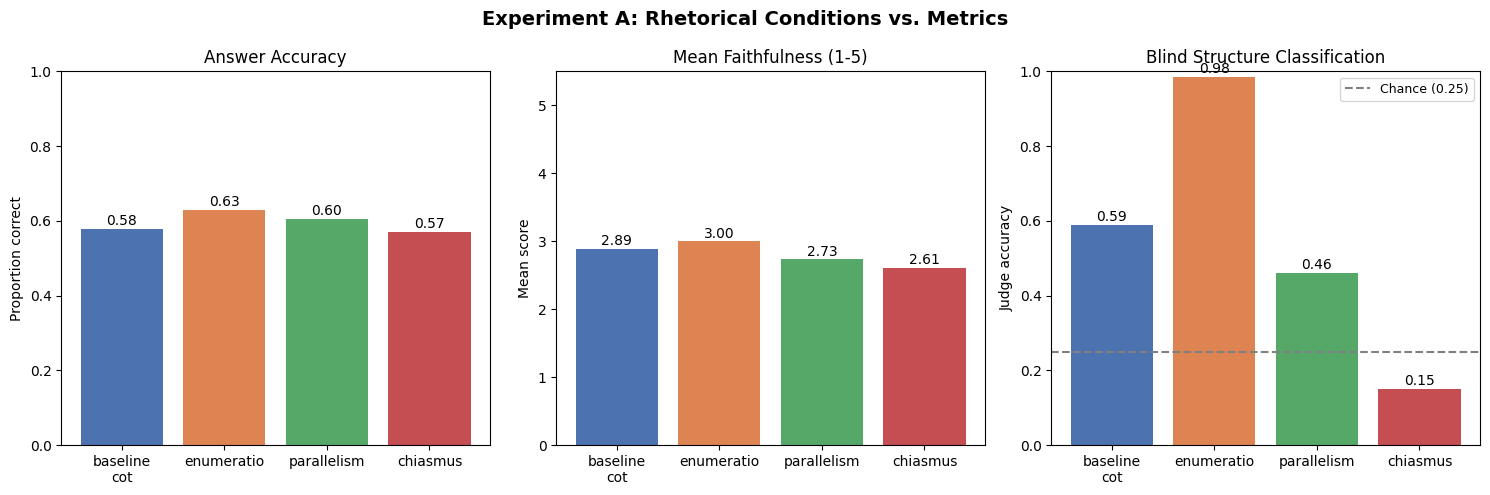

Saved: partA_results_summary.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Experiment A: Rhetorical Conditions vs. Metrics", fontsize=14, fontweight="bold")

condition_labels = [c.replace("_", "\n") for c in CONDITIONS]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
chance = 0.25  # 4-class random baseline for structure classification

# Accuracy
accs = [metrics[c]["accuracy"] for c in CONDITIONS]
axes[0].bar(condition_labels, accs, color=colors)
axes[0].set_title("Answer Accuracy", fontsize=12)
axes[0].set_ylabel("Proportion correct")
axes[0].set_ylim(0, 1)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)

# Faithfulness
faith = [metrics[c]["mean_faithfulness"] for c in CONDITIONS]
axes[1].bar(condition_labels, faith, color=colors)
axes[1].set_title("Mean Faithfulness (1-5)", fontsize=12)
axes[1].set_ylabel("Mean score")
axes[1].set_ylim(0, 5.5)
for i, v in enumerate(faith):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10)

# Blind structure classification accuracy
struct_accs = [metrics[c]["structure_accuracy"] for c in CONDITIONS]
axes[2].bar(condition_labels, struct_accs, color=colors)
axes[2].axhline(chance, color="gray", linestyle="--", label=f"Chance ({chance:.2f})")
axes[2].set_title("Blind Structure Classification", fontsize=12)
axes[2].set_ylabel("Judge accuracy")
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=9)
for i, v in enumerate(struct_accs):
    axes[2].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(main_dir, "partA_results_summary.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: partA_results_summary.png")

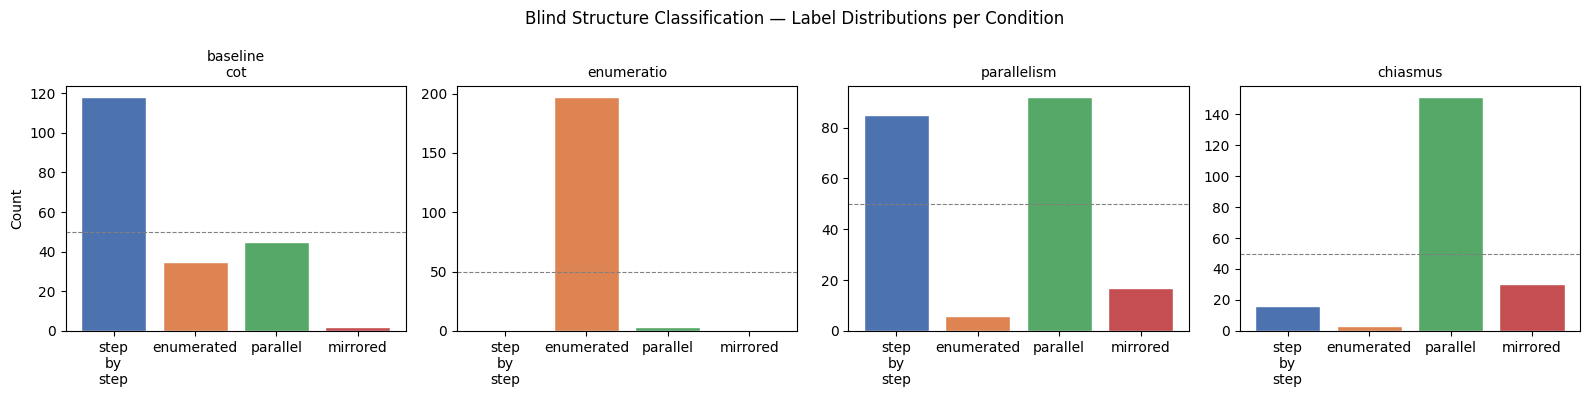

Saved: partA_structure_labels.png


In [ ]:
# Distribution of predicted rhetorical structure labels per condition
all_labels = ["step_by_step", "enumerated", "parallel", "mirrored"]
label_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(16, 4))
fig.suptitle("Blind Structure Classification — Label Distributions per Condition", fontsize=12)

for col, condition in enumerate(CONDITIONS):
    results = all_results[condition]
    label_counts = {l: 0 for l in all_labels}
    for r in results:
        lbl = r.get("predicted_structure")
        if lbl in label_counts:
            label_counts[lbl] += 1

    axes[col].bar(
        [l.replace("_", "\n") for l in all_labels],
        [label_counts[l] for l in all_labels],
        color=label_colors,
        edgecolor="white",
    )
    axes[col].set_title(condition.replace("_", "\n"), fontsize=10)
    axes[col].set_ylabel("Count" if col == 0 else "")
    axes[col].axhline(len(results) / 4, color="gray", linestyle="--", linewidth=0.8, label="Chance")

plt.tight_layout()
plt.savefig(os.path.join(main_dir, "partA_structure_labels.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: partA_structure_labels.png")

## Confusion Matrix (Blind Structure Classification)

This diagnostic shows where the judge confuses rhetorical structures.
- Left: raw counts
- Right: row-normalized rates

Rows = true prompted condition label, columns = predicted label.

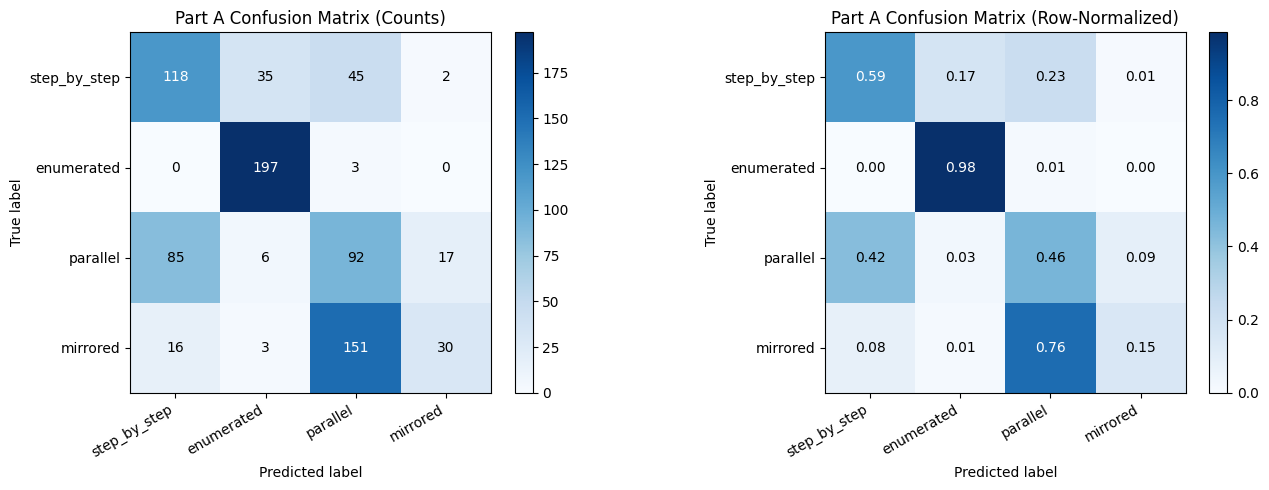

Per-class metrics:
  step_by_step P=0.539  R=0.590  F1=0.563
  enumerated   P=0.817  R=0.985  F1=0.893
  parallel     P=0.316  R=0.460  F1=0.375
  mirrored     P=0.612  R=0.150  F1=0.241
Macro-F1: 0.518
Saved: partA_structure_confusion_matrix.png


In [ ]:
# Part A confusion matrix for blind 4-way structure classification
labels = ["step_by_step", "enumerated", "parallel", "mirrored"]
label_to_idx = {lbl: i for i, lbl in enumerate(labels)}
condition_to_label = {v: k for k, v in LABEL_TO_CONDITION.items()}

y_true, y_pred = [], []
for condition in CONDITIONS:
    true_label = condition_to_label[condition]
    for r in all_results[condition]:
        pred = r.get("predicted_structure")
        if pred in label_to_idx:
            y_true.append(true_label)
            y_pred.append(pred)

cm = np.zeros((len(labels), len(labels)), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[label_to_idx[t], label_to_idx[p]] += 1

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums > 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, title, fmt in [
    (axes[0], cm, "Part A Confusion Matrix (Counts)", "d"),
    (axes[1], cm_norm, "Part A Confusion Matrix (Row-Normalized)", ".2f"),
]:
    im = ax.imshow(mat, cmap="Blues", vmin=0)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    thresh = mat.max() / 2 if mat.size else 0
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            txt = f"{mat[i, j]:{fmt}}"
            color = "white" if mat[i, j] > thresh else "black"
            ax.text(j, i, txt, ha="center", va="center", color=color, fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(os.path.join(main_dir, "partA_structure_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

# Per-class precision/recall/f1 and macro-f1
precision, recall, f1 = {}, {}, {}
for i, lbl in enumerate(labels):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    p = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    r = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    f = 2 * p * r / (p + r) if (p + r) > 0 else float("nan")
    precision[lbl], recall[lbl], f1[lbl] = p, r, f

macro_f1 = np.nanmean(list(f1.values()))
print("Per-class metrics:")
for lbl in labels:
    print(f"  {lbl:<12} P={precision[lbl]:.3f}  R={recall[lbl]:.3f}  F1={f1[lbl]:.3f}")
print(f"Macro-F1: {macro_f1:.3f}")
print("Saved: partA_structure_confusion_matrix.png")